# ============================================================
 FIFA WORLD CUP 2026 - BALL POSSESSION ANALYSIS

 Analytic Question:
 Is there a significant difference in the average
 ball possession percentage between winning and
 losing teams in FIFA World Cup 2026 matches?
# ============================================================

In [1]:
# ============================================================
# Import libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# Load dataset
# ============================================================

file_path = "FIFA_WC2026_Possession_Cleaned.csv"
df = pd.read_csv(file_path)

# Check rows and columns of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# View dataset info
print("\n----First 5 rows: ----")
print(df.head())
print("\n")
print(df.info())

Rows: 208
Columns: 5

----First 5 rows: ----
   MatchID                      Match            Team Result  \
0        1     Mexico vs South Africa          Mexico    Win   
1        1     Mexico vs South Africa    South Africa   Loss   
2        2  Korea Republic vs Czechia  Korea Republic    Win   
3        2  Korea Republic vs Czechia         Czechia   Loss   
4        3      Canada vs Bosnia–Herz          Canada   Draw   

   Ball_Possession_pct  
0                   61  
1                   40  
2                   62  
3                   38  
4                   61  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   MatchID              208 non-null    int64 
 1   Match                208 non-null    object
 2   Team                 208 non-null    object
 3   Result               208 non-null    object
 4   Ball_Possession

In [3]:
# ============================================================
# Data Preparation
# ============================================================

# Analytic task focus on winning and losing teams only
# Therefore, remove drawn matches
df_win_loss = df[df["Result"].isin(["Win", "Loss"])].copy()

print("Rows after removing draw matches: ", len(df_win_loss))

print("\n----Display the number of observations for each team: ----")
print(df_win_loss["Result"].value_counts())

Rows after removing draw matches:  160

----Display the number of observations for each team: ----
Result
Win     80
Loss    80
Name: count, dtype: int64


In [4]:
# ============================================================
# Separate the data into two groups: winning and losing teams
# ============================================================

df_win = df_win_loss[df_win_loss["Result"] == "Win"]
df_loss = df_win_loss[df_win_loss["Result"] == "Loss"]

print("Winning teams:", len(df_win))
print("Losing teams:", len(df_loss))

Winning teams: 80
Losing teams: 80


In [5]:
# ============================================================
# Outlier Detection using IQR method
# ============================================================

# Create a new column "Outlier" to mark which team is outlier
df_win_loss["Outlier"] = "No"

for group in ["Win", "Loss"]:

    data = df_win_loss[df_win_loss["Result"] == group]

    Q1 = data["Ball_Possession_pct"].quantile(0.25)
    Q3 = data["Ball_Possession_pct"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outlier_condition = (
        (df_win_loss["Result"] == group) &
        (
            (df_win_loss["Ball_Possession_pct"] < lower_bound) |
            (df_win_loss["Ball_Possession_pct"] > upper_bound)
        )
    )

    # Mark outliers
    df_win_loss.loc[outlier_condition, "Outlier"] = "Yes"

    # Get outlier rows
    outliers = df_win_loss[outlier_condition]

    print(f"\n---- Team: {group} ----")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")

    print("\nNumber of possible outliers:", len(outliers))
    print(f"\n---- Outliers ({group}) ----")

    print(
        outliers[
            [
                "Match",
                "Team",
                "Result",
                "Ball_Possession_pct"
            ]
        ]
    )


---- Team: Win ----
Q1: 50.50
Q3: 64.00
IQR: 13.50
Lower bound: 30.25
Upper bound: 84.25

Number of possible outliers: 2

---- Outliers (Win) ----
                   Match       Team Result  Ball_Possession_pct
12  Australia vs Türkiye  Australia    Win                   28
61   Türkiye vs Paraguay   Paraguay    Win                   22

---- Team: Loss ----
Q1: 36.75
Q3: 49.50
IQR: 12.75
Lower bound: 17.62
Upper bound: 68.62

Number of possible outliers: 3

---- Outliers (Loss) ----
                              Match            Team Result  \
13             Australia vs Türkiye         Türkiye   Loss   
60              Türkiye vs Paraguay         Türkiye   Loss   
105  South Africa vs Korea Republic  Korea Republic   Loss   

     Ball_Possession_pct  
13                    72  
60                    79  
105                   69  


The IQR method identified possible outliers in both winning and losing teams.

After checking these observations against the original data source, the ball possession values were confirmed to be valid.

Therefore, the original values were retained, and no outliers were removed.

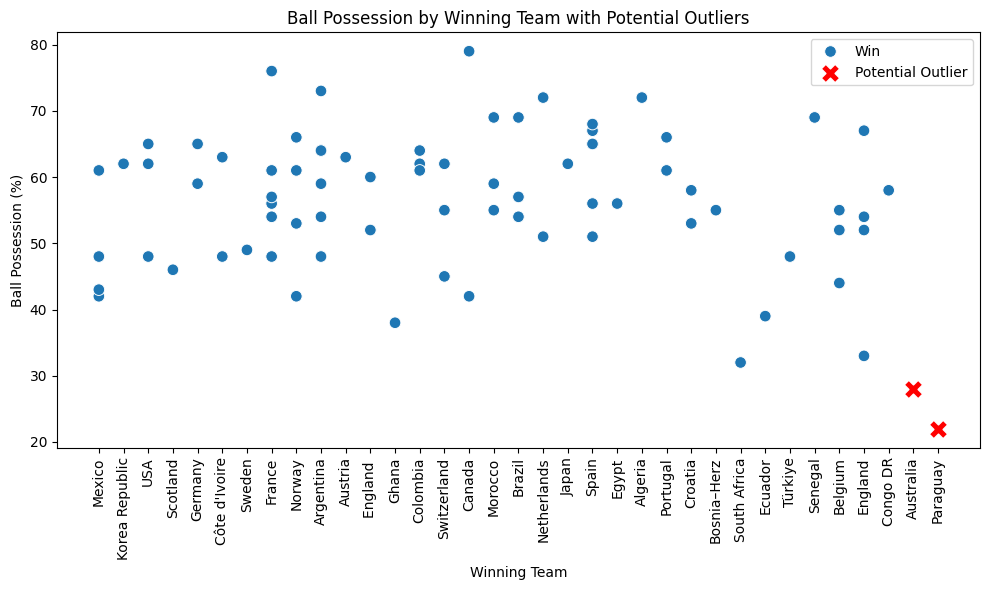

In [6]:
# ============================================================
# Scatter Plot for Outlier Detection in Winning Team
# ============================================================

# Create a dataframe for the winning teams
df_winning = df_win_loss[df_win_loss["Result"] == "Win"]

plt.figure(figsize=(10, 6))

# Normal observations
sns.scatterplot(
    data=df_winning[df_winning["Outlier"] == "No"],
    x="Team",
    y="Ball_Possession_pct",
    hue="Result",
    s=70
)

# Outliers
sns.scatterplot(
    data=df_winning[df_winning["Outlier"] == "Yes"],
    x="Team",
    y="Ball_Possession_pct",
    marker="X",
    s=180,
    color="red",
    label="Potential Outlier"
)

plt.xticks(rotation=90)
plt.xlabel("Winning Team")
plt.ylabel("Ball Possession (%)")
plt.title("Ball Possession by Winning Team with Potential Outliers")
plt.tight_layout()
plt.show()

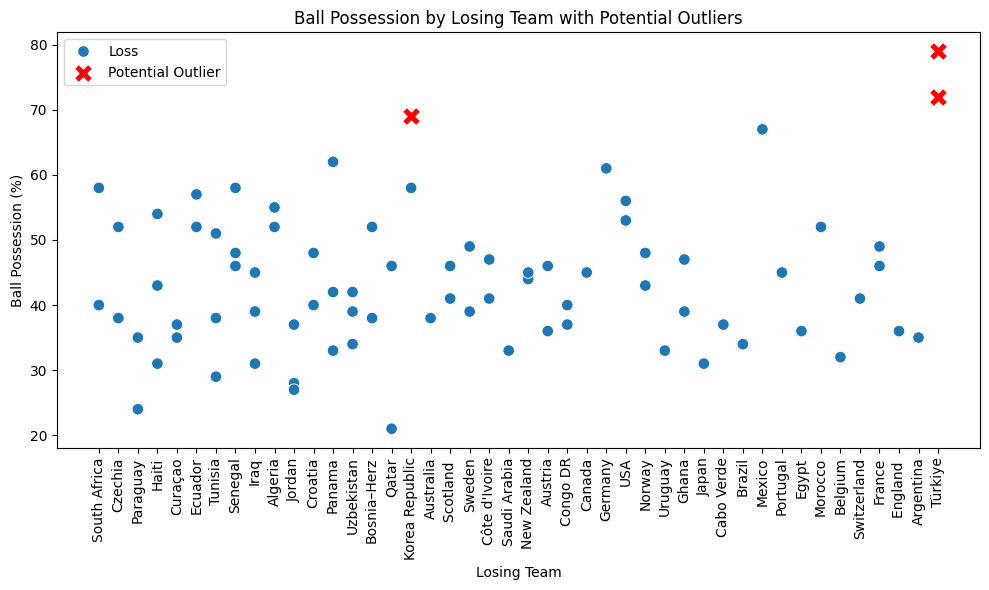

In [7]:
# ============================================================
# Scatter Plot for Outlier Detection in Losing Team
# ============================================================

# Create a dataframe for the losing teams
df_losing = df_win_loss[df_win_loss["Result"] == "Loss"]

plt.figure(figsize=(10, 6))

# Normal observations
sns.scatterplot(
    data=df_losing[df_losing["Outlier"] == "No"],
    x="Team",
    y="Ball_Possession_pct",
    hue="Result",
    s=70
)

# Outliers
sns.scatterplot(
    data=df_losing[df_losing["Outlier"] == "Yes"],
    x="Team",
    y="Ball_Possession_pct",
    marker="X",
    s=180,
    color="red",
    label="Potential Outlier"
)

plt.xticks(rotation=90)
plt.xlabel("Losing Team")
plt.ylabel("Ball Possession (%)")
plt.title("Ball Possession by Losing Team with Potential Outliers")
plt.tight_layout()
plt.show()

Sampling Method

The data were separated into winning and losing groups. First, a random sample of 40 winning observations was taken. Losses with the same MatchIDs were removed before randomly selecting 40 losses to ensure independence, which is required for the two-sample t-test. This gave two samples of size 40 (no overlapping matches).

In [8]:
# ============================================================
# Data Sampling
# ============================================================

# Randomly select 40 winning observations
sample_win = df_win.sample(
    n=40,
    random_state=42
)

# Get MatchIDs already selected for the winning sample
selected_win_matches = sample_win["MatchID"].unique()

# Exclude those matches from the losing group
df_loss_available = df_loss[
    ~df_loss["MatchID"].isin(selected_win_matches)
]

# Randomly select 40 losing observations from different matches
sample_loss = df_loss_available.sample(
    n=40,
    random_state=42
)

print("---- Sample data of winning teams: ----")
print(sample_win.head())

print("\n---- Sample data of losing teams: ----")
print(sample_loss.head())

---- Sample data of winning teams: ----
    MatchID                   Match         Team Result  Ball_Possession_pct
87       44       Jordan vs Algeria      Algeria    Win                   72
0         1  Mexico vs South Africa       Mexico    Win                   61
64       33   Netherlands vs Sweden  Netherlands    Win                   51
88       45  Portugal vs Uzbekistan     Portugal    Win                   66
56       29        USA vs Australia          USA    Win                   62

---- Sample data of losing teams: ----
     MatchID                           Match            Team Result  \
105       53  South Africa vs Korea Republic  Korea Republic   Loss   
92        47               Panama vs Croatia          Panama   Loss   
85        43               Norway vs Senegal         Senegal   Loss   
159       80            England  vs Congo DR        Congo DR   Loss   
33        17               France vs Senegal         Senegal   Loss   

     Ball_Possession_pct  
105 

In [9]:
# ============================================================
# Check for Overlapping Matches
# ============================================================

win_matches = set(sample_win["MatchID"])
loss_matches = set(sample_loss["MatchID"])

overlapping_matches = win_matches.intersection(loss_matches)

print("Number of overlapping matches:", len(overlapping_matches))
print("Overlapping MatchIDs:", overlapping_matches)

Number of overlapping matches: 0
Overlapping MatchIDs: set()


In [10]:
# ============================================================
# Combining the Two Samples into a Single Dataset
# ============================================================

sample_df = pd.concat(
    [sample_win, sample_loss],
    ignore_index=True
)

# Check the final sample size
print("Total sample size:", len(sample_df))

# Check counts for the sample in each team
print(sample_df["Result"].value_counts())

Total sample size: 80
Result
Win     40
Loss    40
Name: count, dtype: int64


In [11]:
# ============================================================
# Save sample dataset as a new CSV file
# ============================================================

sample_df.to_csv(
    "FIFA_WC2026_Possession_Final_Sample.csv",
    index=False
)

print("CSV file saved successfully.")

CSV file saved successfully.
